###### Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai_jobs_market_2025_2026.csv')

df.head(10)

# https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)
5,AIJOB0006,AI Agent Developer,AI Engineering,Entry (0-2 yrs),5,Bootcamp/Self-taught,155000.0,155000,290000,Chicago,...,8.0,96,67.7,8.7,2026,1,0,0,1,Upper-Mid ($150-200k)
6,AIJOB0007,AI Security Engineer,Security,Mid (3-5 yrs),5,Master's,197000.0,140000,260000,Boston,...,16.3,80,12.7,6.2,2026,1,0,1,0,Upper-Mid ($150-200k)
7,AIJOB0008,Senior ML Engineer,AI Engineering,Mid (3-5 yrs),7,Master's,221000.0,180000,312000,Remote,...,12.5,96,33.1,6.2,2025,9,0,1,0,Senior ($200-300k)
8,AIJOB0009,NLP Engineer,AI Engineering,Entry (0-2 yrs),3,Bachelor's,145000.0,145000,290000,Bangalore,...,8.1,91,79.4,8.2,2025,8,0,1,0,Mid ($100-150k)
9,AIJOB0010,Prompt Engineer,AI Engineering,Entry (0-2 yrs),4,Bootcamp/Self-taught,90000.0,90000,200000,Los Angeles,...,6.1,82,15.5,7.1,2025,2,0,0,1,Entry (<$100k)


# AI Jobs Market 2025-2026 | Salaries, Skills & Demand

This dataset captures 1,500 AI and machine learning job postings from 2025–2026 across 25 roles, 14 countries, and 12 industries. It highlights emerging positions like **LLM Engineer** and **AI Agent Developer**, and includes information on salaries, skills, and market demand.

---

## Features

| Column | Description | Example / Range |
| :--- | :--- | :--- |
| **job_id** | Unique job identifier | AIJOB0001 |
| **job_title** | Specific AI/ML role | LLM Engineer, Prompt Engineer |
| **job_category** | Broad role type | AI Engineering, Data Science |
| **experience_level** | Seniority level | Entry, Mid, Senior, Lead |
| **years_of_experience** | Minimum experience required | 1–15 years |
| **education_required** | Minimum education | Bachelor's, Master's, PhD |
| **annual_salary_usd** | Total annual pay | $90,000–$384,000 |
| **salary_min_usd** | Minimum salary | $90,000–$180,000 |
| **salary_max_usd** | Maximum salary | $180,000–$320,000 |
| **city** | Job location | San Francisco, London, Berlin |
| **country** | Country of employment | USA, UK, Germany, Singapore |
| **remote_work** | Work arrangement | On-site, Hybrid, Fully Remote |
| **company_size** | Organization scale | Startup, SME, Mid-size, Enterprise, Big Tech |
| **industry** | Company sector | Technology, Finance, Healthcare |
| **required_skills** | Key technical skills | Python, PyTorch, LLMs, NLP |
| **ai_salary_premium_pct** | Premium vs non-AI roles | 3–18% |
| **demand_score** | Market demand | 0–100 |
| **demand_growth_yoy_pct** | Yearly growth in demand | 5–87.8% |
| **benefits_score_10** | Benefits quality | 0–10 |
| **posting_year** | Year listed | 2025, 2026 |
| **posting_month** | Month listed | 1–12 |
| **is_senior** | Seniority flag | 0 = No, 1 = Yes |
| **is_remote_friendly** | Remote-friendly flag | 0 = No, 1 = Yes |
| **is_llm_role** | Generative AI/LLM focus | 0 = No, 1 = Yes |
| **salary_tier** | Salary category | Entry, Mid, Upper-Mid, Senior, Elite |

---

## Target Feature

**`demand_score`** – Indicates how in-demand a role is (0–100). This will be used to analyze how factors like experience, salary, and role type affect market demand.

C:\Users\kamet\AppData\Local\Temp\ipykernel_52372\1326044497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_demand, x='job_category', y='demand_score', palette='viridis')


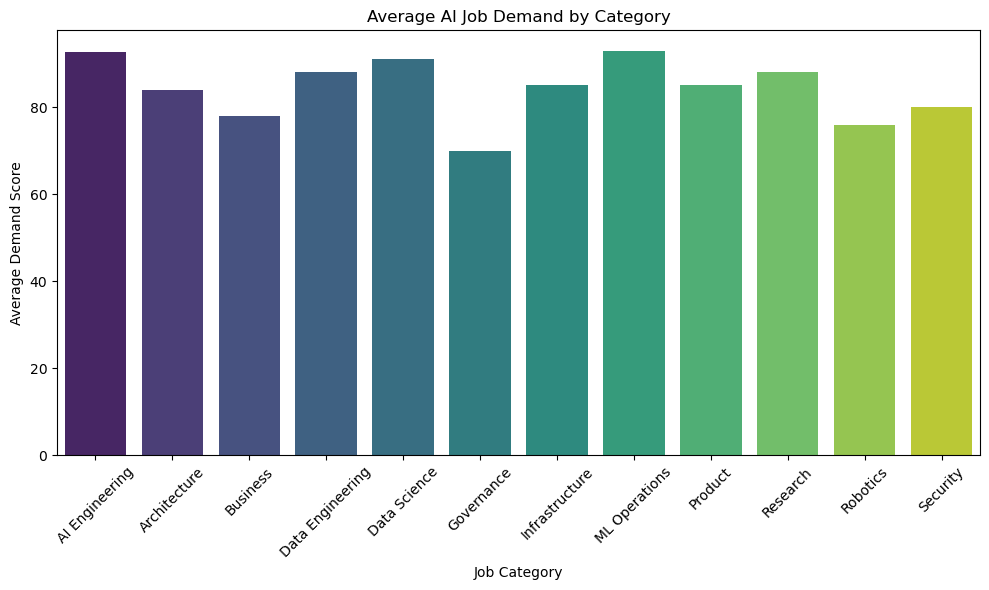

In [10]:
# -------------------------------
# 1. Job Category vs Demand Score
# -------------------------------
category_demand = df.groupby('job_category')['demand_score'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=category_demand, x='job_category', y='demand_score', palette='viridis')
plt.xticks(rotation=45)
plt.title("Average AI Job Demand by Category")
plt.ylabel("Average Demand Score")
plt.xlabel("Job Category")
plt.tight_layout()
plt.show()

### Job Category vs Demand Score
Job Category shows the clearest relationship with demand score.
AI Engineering and ML Operations rank the highest (~92–93), while
Governance ranks the lowest (~70). This ~20 point gap shows that
the *type of role* you work in has a real impact on how in-demand you are.

C:\Users\kamet\AppData\Local\Temp\ipykernel_52372\4186350998.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


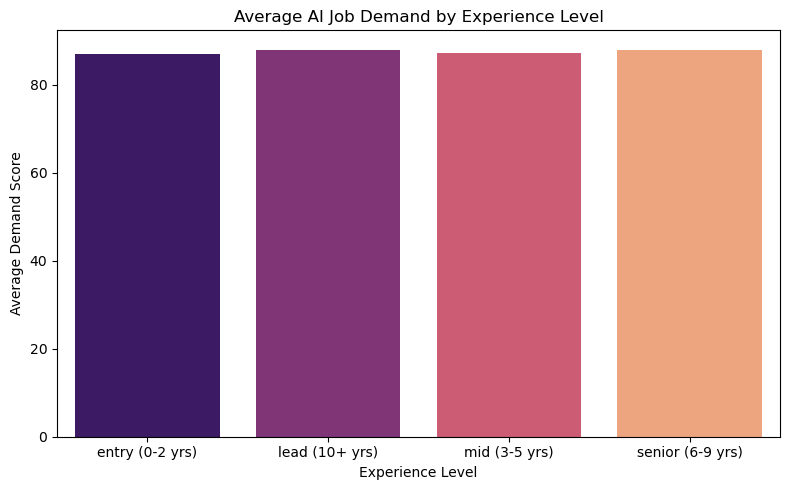

In [18]:
# ---------------------------------
# 2. Experience Level vs Demand Score
# ---------------------------------

# Clean values (safe normalization)
df['experience_level'] = df['experience_level'].astype(str).str.strip().str.lower()

# Group
exp_demand = df.groupby('experience_level')['demand_score'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=exp_demand,
    x='experience_level',
    y='demand_score',
    palette='magma'
)

plt.title("Average AI Job Demand by Experience Level")
plt.ylabel("Average Demand Score")
plt.xlabel("Experience Level")
plt.tight_layout()
plt.show()

### Experience Level vs Demand Score
Experience level shows almost no relationship with demand score.
Entry, Mid, Senior, and Lead roles all score between 87–88 —
nearly identical. This tells us that AI roles are in high demand
regardless of seniority, meaning even entry-level candidates are
just as sought after as senior ones.

C:\Users\kamet\AppData\Local\Temp\ipykernel_52372\2587511741.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_demand, x='city', y='demand_score', palette='coolwarm')


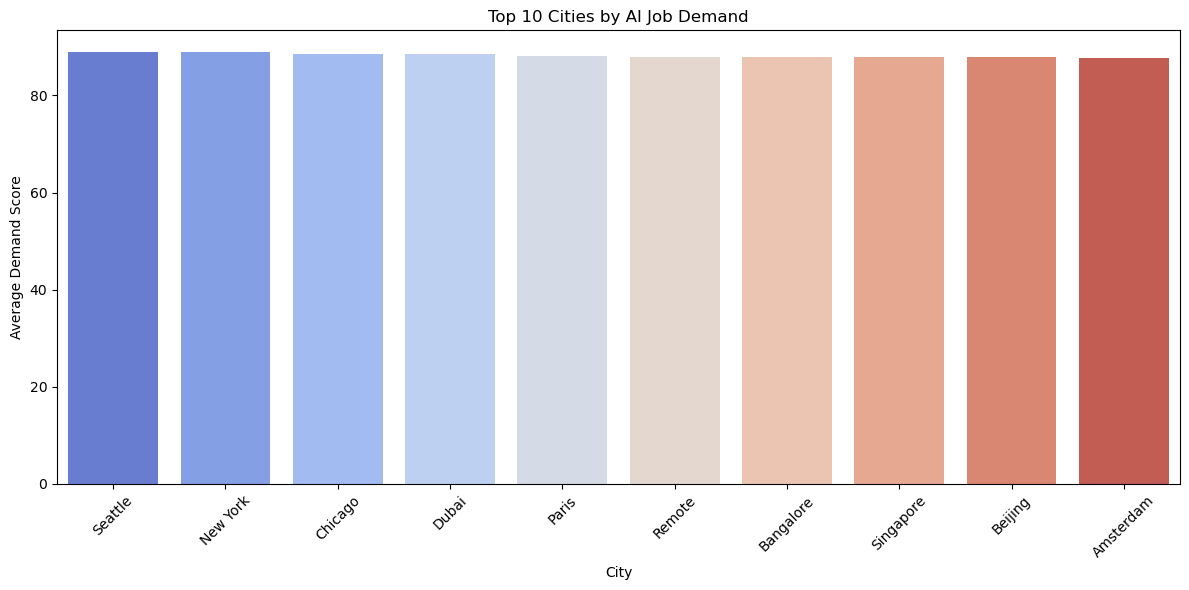

In [12]:
# -------------------------------
# 3. City vs Demand Score (Top 10)
# -------------------------------
city_demand = df.groupby('city')['demand_score'].mean().reset_index().sort_values(by='demand_score', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=city_demand, x='city', y='demand_score', palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Top 10 Cities by AI Job Demand")
plt.ylabel("Average Demand Score")
plt.xlabel("City")
plt.tight_layout()
plt.show()

### City vs Demand Score (Top 10)
City location shows very little relationship with demand score.
The top 10 cities — including Seattle, New York, Dubai, and Singapore,
all score between 87–90, with barely any difference between them.
This suggests that AI job demand is globally consistent and not
concentrated in any one city.

C:\Users\kamet\AppData\Local\Temp\ipykernel_52372\2223105779.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=edu_demand, x='education_required', y='demand_score', palette='Set2')


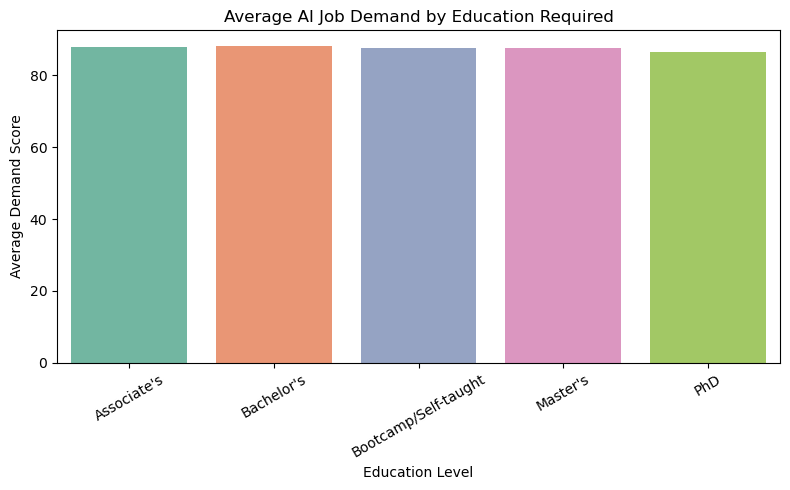

In [13]:
# ---------------------------------
# 4. Education Required vs Demand Score
# ---------------------------------
edu_demand = df.groupby('education_required')['demand_score'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=edu_demand, x='education_required', y='demand_score', palette='Set2')
plt.xticks(rotation=30)
plt.title("Average AI Job Demand by Education Required")
plt.ylabel("Average Demand Score")
plt.xlabel("Education Level")
plt.tight_layout()
plt.show()

### Education Required vs Demand Score
Education level has almost no influence on demand score.
Bachelor's, Master's, and PhD requirements all produce nearly
identical demand scores. This means employers across the AI field
value the role itself more than the degree level, a Bachelor's
degree is just as likely to land you an in-demand position as a PhD.

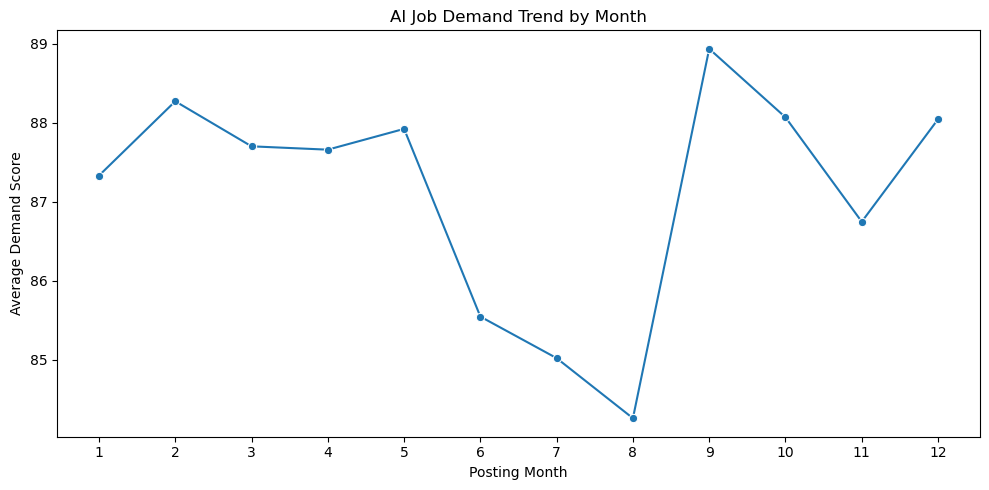

In [14]:
# -------------------------------
# 5. Posting Month vs Demand Score
# -------------------------------
month_demand = df.groupby('posting_month')['demand_score'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=month_demand, x='posting_month', y='demand_score', marker='o')
plt.title("AI Job Demand Trend by Month")
plt.xlabel("Posting Month")
plt.ylabel("Average Demand Score")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

### Posting Month vs Demand Score
Posting month shows a noticeable seasonal pattern.
Demand is relatively stable from January to May, then drops
significantly through summer, hitting its lowest point in August (84).
It then sharply rebounds in September to the highest point of the year (89),
before dipping again in November. This suggests AI hiring slows in
summer and peaks in the fall.

## Conclusions

### Which features seem most related to demand score?

**Job Category** is the most related feature. There are clear differences
between categories. AI Engineering and ML Operations score the highest (92–93),
while Governance scores the lowest (70). This 20 point gap shows that
*what type of role* you are in actually affects how in-demand it is.

**Posting Month** also shows a real seasonal pattern. Demand drops during
summer (June–August), hitting its lowest point in August (84), then
sharply rebounds in September to the highest point of the year (89).
This suggests AI hiring slows in summer and picks back up in the fall.



### Which features don't seem to influence demand score?

**City**: the top 10 cities all score nearly the same (~87–90).
Whether the job is in Seattle, Dubai, or Singapore, demand stays flat.
Location doesn't seem to change how in-demand an AI role is.

**Experience Level**: Entry, Mid, Senior, and Lead all sit around 87–88.
Seniority has almost no effect on demand, meaning AI roles are equally
sought after at every career stage.

**Education Required**: Bachelor's, Master's, and PhD roles show almost
no difference in demand score. Employers seem to want these roles
equally regardless of degree level.



### Big Picture Conclusion

In the AI job market, **what kind of role you're in and when you apply
matters more than where you work, how experienced you are, or what degree
you have**. AI Engineering and ML Operations are the highest-demand
categories, while Governance lags behind. Timing also plays a role, avoid job hunting in summer and aim for September when demand peaks.
For anyone entering the AI field, focusing on the *right role type*
at the *right time of year* gives the best chance of landing a high-demand position.